In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import anndata as ad
import numpy as np
ad.settings.allow_write_nullable_strings = True

sc.settings.verbosity = 3


In [2]:
h5ad_path = "/Users/qgem/GitHub/PBMC3k-reproducible/data/objects/pbmc3k_norm.h5ad"
def load_evidence(h5ad_path):

    # Loads the QC-cleaned artifact from P04 file
    print(f"   -> Loading QC artifact from: {h5ad_path}")
    adata = sc.read_h5ad(h5ad_path)
    print(f"   -> Loaded dimensions: {adata.n_obs} cells x {adata.n_vars} genes")
    return adata

In [3]:
def pca(adata):
    sc.pp.pca(adata,n_comps=100,zero_center=True,svd_solver='arpack',
              mask_var='highly_variable')
    return adata

    

In [ ]:
def screeplot(adata,stagename):
    sc.pl.pca_variance_ratio(adata,n_pcs=50,save=f"_{stagename}.png")
    
    plt.show()



   -> Loading QC artifact from: /Users/qgem/GitHub/PBMC3k-reproducible/data/objects/pbmc3k_norm.h5ad
   -> Loaded dimensions: 2536 cells x 13456 genes
computing PCA
    with n_comps=100
    finished (0:00:00)


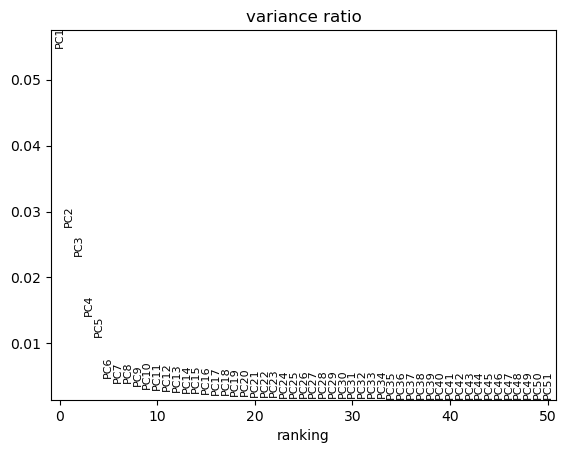

KeyError: 'Could not find key gene_ids in .var_names or .obs.columns.'

<Figure size 2911.2x1440 with 0 Axes>

In [5]:
if __name__ == '__main__':
    adata = load_evidence(h5ad_path)
    adata = pca(adata)
    screeplot(adata,'pca_elbow')
    